# Projet DDDM — Prédiction des Incendies de Forêts au Maroc
Ce notebook présente l'analyse exploratoire des données (EDA), les tests statistiques, la segmentation des risques par clustering et la modélisation prédictive avec interprétabilité SHAP.

## 1. Chargement & Audit des Données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Assurer l'import de nos scripts locaux
sys.path.append('../')
from src.data_loader import load_raw_data, run_data_audit, get_data_dictionary
from src.preprocessor import clean_data, perform_feature_engineering, prepare_ml_datasets

df_raw = load_raw_data('../data')
print("Dimensions :", df_raw.shape)
df_raw.head(3)

Dimensions : (100000, 278)


,acq_date,latitude,longitude,is_holiday,day_of_week,day_of_year,is_weekend,NDVI,SoilMoisture,sea_distance,...,wind_gust_quarterly_mean,dew_point_quarterly_mean,average_temperature_yearly_mean,maximum_temperature_yearly_mean,minimum_temperature_yearly_mean,precipitation_yearly_mean,snow_depth_yearly_mean,wind_gust_yearly_mean,dew_point_yearly_mean,is_fire
0,2015-05-28,31.390602,-4.254445,0.0,3.0,148.0,0.0,1139.0,7.0,464731.94,...,882.0856,27.641111,71.70301,82.031784,58.668766,2.213260,999.9,857.07180,32.760273,1.0
1,2017-12-05,33.832943,-5.188356,0.0,1.0,339.0,0.0,3223.0,31.0,186799.98,...,936.8174,52.452175,65.62172,80.128555,53.295628,2.256421,999.9,864.04834,47.819126,1.0
2,2021-11-19,35.385690,-5.684218,0.0,4.0,323.0,0.0,4987.0,30.0,44937.30,...,884.2891,65.556520,66.10874,74.353830,58.815575,0.050738,999.9,806.45685,56.298634,1.0


### Dictionnaire de données

In [2]:
get_data_dictionary()

,Column,Type,Source,Description
0,acq_date,Date / Chaîne de caractères,NASA FIRMS,Date d'acquisition des observations satellites.
1,latitude,Flottant,NASA FIRMS,Latitude de la zone d'observation au Maroc.
2,longitude,Flottant,NASA FIRMS,Longitude de la zone d'observation au Maroc.
3,NDVI,Flottant,MODIS (Vegetation Index),Indice de végétation par différence normalisée...
4,SoilMoisture,Flottant,NASA/USDA,Humidité du sol (quantité d'eau retenue dans l...
5,sea_distance,Flottant,Calculé,Distance la plus proche par rapport à la mer/o...
6,average_temperature_lag_1,Flottant,NOAA GSOD,Température moyenne observée la veille (lag 1)...
7,precipitation_lag_1,Flottant,NOAA GSOD,Précipitations observées la veille (lag 1) en ...
8,wind_speed_lag_1,Flottant,NOAA GSOD,Vitesse du vent enregistrée la veille (lag 1).
9,dew_point_lag_1,Flottant,NOAA GSOD,Point de rosée de la veille (lag 1) indiquant ...


### Audit Qualité des Données

In [3]:
audit = run_data_audit(df_raw)
print("Doublons :", audit['duplicates'])
print("Distribution de is_fire :", audit['target_distribution'])
print("Pourcentage d'incendies :", f"{audit['fire_percentage']:.2f}%")

Doublons : 0
Distribution de is_fire : {0.0: 50200, 1.0: 49800}
Pourcentage d'incendies : 49.80%


## 2. Analyse Exploratoire des Données (EDA) & Feature Engineering

In [4]:
df_cleaned = clean_data(df_raw)
df_engineered = perform_feature_engineering(df_cleaned)
print("Features créées. Aperçu du FWI moyen par région :")
df_engineered.groupby('Region')['fwi_index'].mean()

Features créées. Aperçu du FWI moyen par région :


Region
Centre    28.722554
Nord      27.820314
Sud       30.107031
Name: fwi_index, dtype: float64

### Visualisation 1 : Distribution des Températures Celsius

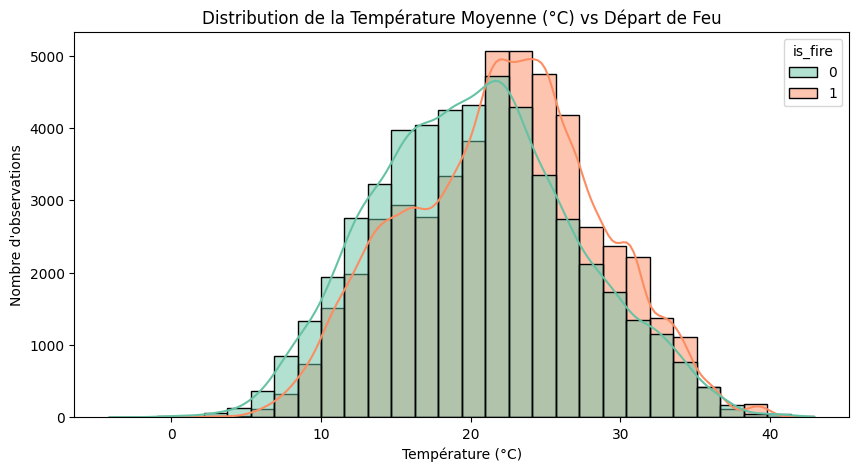

In [5]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df_engineered, x='temp_avg_c', hue='is_fire', kde=True, bins=30, palette='Set2')
plt.title('Distribution de la Température Moyenne (°C) vs Départ de Feu')
plt.xlabel('Température (°C)')
plt.ylabel('Nombre d\'observations')
plt.show()

### Visualisation 2 : Indice FWI par Région

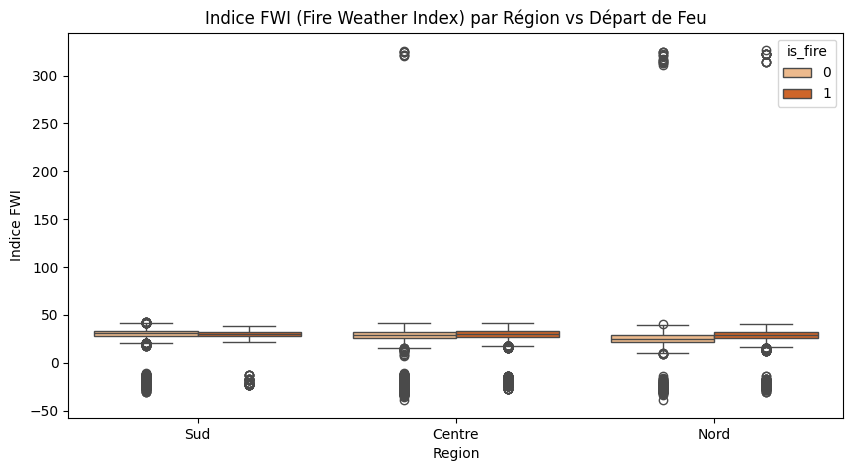

In [6]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_engineered, x='Region', y='fwi_index', hue='is_fire', palette='Oranges')
plt.title('Indice FWI (Fire Weather Index) par Région vs Départ de Feu')
plt.ylabel('Indice FWI')
plt.show()

### Visualisation 3 : Matrice de Corrélation des Variables Clés

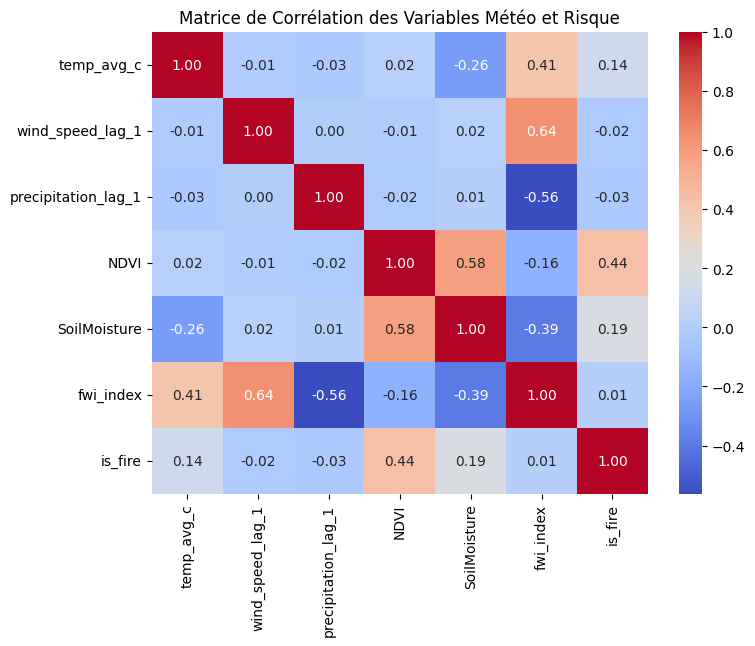

In [7]:
key_cols = ['temp_avg_c', 'wind_speed_lag_1', 'precipitation_lag_1', 'NDVI', 'SoilMoisture', 'fwi_index', 'is_fire']
plt.figure(figsize=(8, 6))
sns.heatmap(df_engineered[key_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matrice de Corrélation des Variables Météo et Risque')
plt.show()

## 3. Tests Statistiques

### Test 1 : Test t de Student (Température Moyenne vs is_fire)
Hypothèse Nulle ($H_0$) : La température moyenne de la veille est identique pour les jours avec et sans feu.

In [8]:
from scipy import stats
temp_fire = df_engineered[df_engineered['is_fire'] == 1]['temp_avg_c']
temp_no_fire = df_engineered[df_engineered['is_fire'] == 0]['temp_avg_c']

t_stat, p_val = stats.ttest_ind(temp_fire, temp_no_fire, equal_var=False)
print(f"Statistique t : {t_stat:.4f}")
print(f"p-value : {p_val:.6e}")

Statistique t : 43.5223
p-value : 0.000000e+00


### Test 2 : Test du Chi-deux d'Indépendance (Région vs is_fire)
Hypothèse Nulle ($H_0$) : La distribution des incendies est indépendante de la région.

In [9]:
contingency = pd.crosstab(df_engineered['Region'], df_engineered['is_fire'])
chi2, p_val, dof, expected = stats.chi2_contingency(contingency)
print("Table de contingence :\n", contingency)
print(f"Statistique Chi-deux : {chi2:.4f}")
print(f"p-value : {p_val:.6e}")

Table de contingence :
 is_fire      0      1
Region               
Centre   19184  16363
Nord      8217  29587
Sud      22799   3850
Statistique Chi-deux : 25776.6563
p-value : 0.000000e+00


## 4. Clustering (Segmentation K-Means)

In [10]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

km_features = ['latitude', 'longitude', 'fwi_index']
scaler_km = StandardScaler()
scaled_km = scaler_km.fit_transform(df_engineered[km_features])

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_engineered['Risk_Cluster'] = kmeans.fit_predict(scaled_km)

profiles = df_engineered.groupby('Risk_Cluster').agg({
    'is_fire': 'mean',
    'temp_avg_c': 'mean',
    'wind_speed_lag_1': 'mean',
    'latitude': 'count'
}).rename(columns={'latitude': 'Observations'})
profiles

,is_fire,temp_avg_c,wind_speed_lag_1,Observations
Risk_Cluster,,,,
0,0.627671,21.309640,6.561192,69718
1,0.199226,21.013283,7.577538,30247
2,0.400000,13.715873,999.900000,35


## 5. Modélisation Prédictive & Interprétabilité

In [11]:
X_train, X_test, y_train, y_test, scaler, features = prepare_ml_datasets(df_engineered)
print("Taille X_train :", X_train.shape)

Taille X_train : (80000, 20)


### Entraînement et Comparaison des Modèles

In [12]:
from src.models import train_and_evaluate_models, calculate_shap_explainer
report, models = train_and_evaluate_models(X_train, X_test, y_train, y_test)
report

Entraînement de la Régression Logistique...
Entraînement de la Forêt Aléatoire...
Entraînement de XGBoost...


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Régression Logistique,0.80340,0.782315,0.838554,0.809459,0.879755
1,Random Forest,0.90740,0.887646,0.932028,0.909296,0.973192
2,XGBoost,0.93185,0.920227,0.945080,0.932488,0.982287


### Interprétabilité SHAP du Meilleur Modèle

Meilleur modèle : XGBoost
Calcul de SHAP...


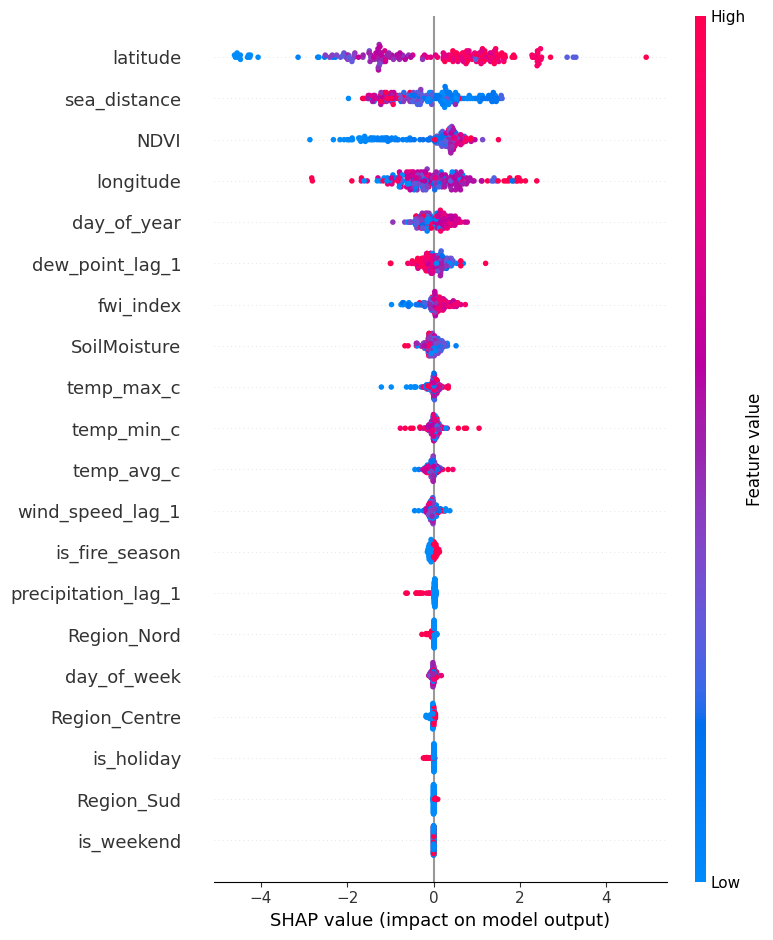

In [13]:
best_model_name = report.sort_values(by='F1-Score', ascending=False).iloc[0]['Model']
best_model = models[best_model_name]
print("Meilleur modèle :", best_model_name)

explainer, shap_values = calculate_shap_explainer(best_model, X_train, X_test)
if shap_values is not None:
    import shap
    shap.summary_plot(shap_values, X_test.head(200))
else:
    print("SHAP non disponible.")